In [1]:
import re
import numpy as np
import assembly_pool as ap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from tqdm import tqdm

In [2]:
a = ap.AssemblyPool(50,50)
evolution = a.evolve(10000)


Calculating iterations: 100%|██████████| 10000/10000 [00:58<00:00, 170.16it/s]


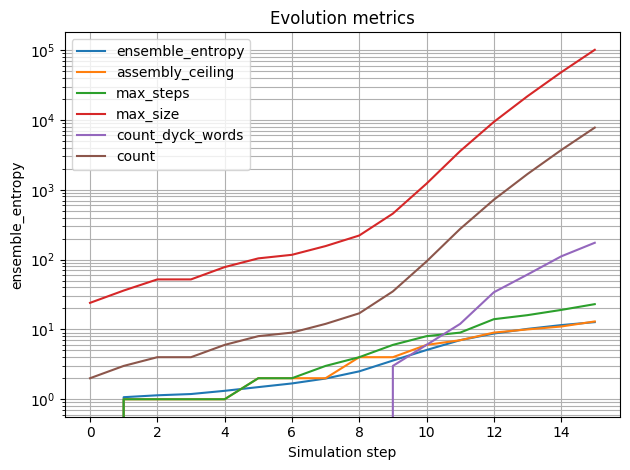

In [3]:
ap.evol_graph(evolution)

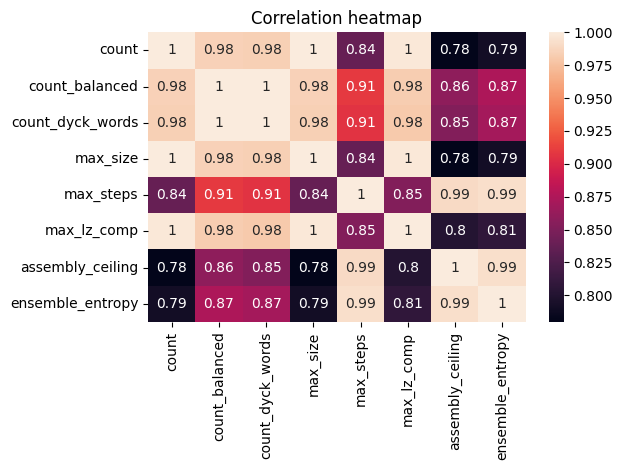

In [4]:
sns.heatmap(evolution.corr(),annot=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [51]:
a.pool['size'] = a.pool.element.str.len() 
a.pool['balanced'] = np.abs(a.pool.element.str.count("0") - a.pool.element.str.count("1"))<= 1

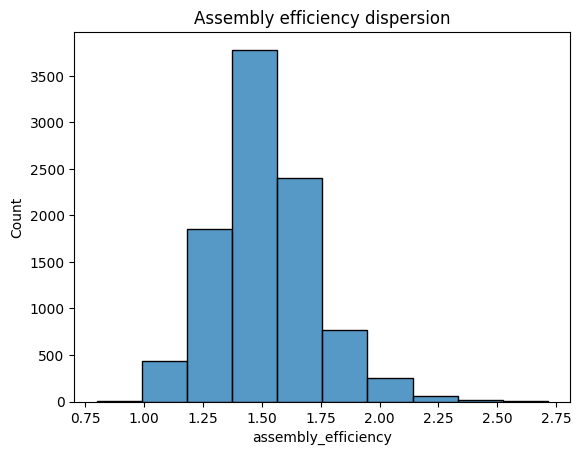

In [52]:
sns.histplot(a.pool.assembly_efficiency,bins=10 )
plt.title("Assembly efficiency dispersion")
plt.show()

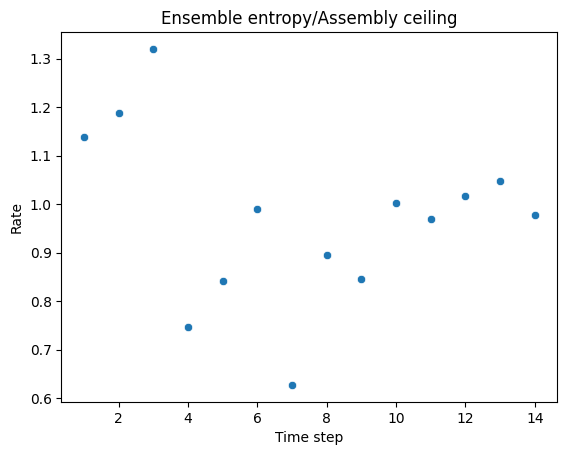

In [53]:
rate = evolution.ensemble_entropy/evolution.assembly_ceiling
sns.scatterplot(x =evolution.index,y = rate)
plt.title("Ensemble entropy/Assembly ceiling")
plt.xlabel("Time step")
plt.ylabel("Rate")
plt.show()

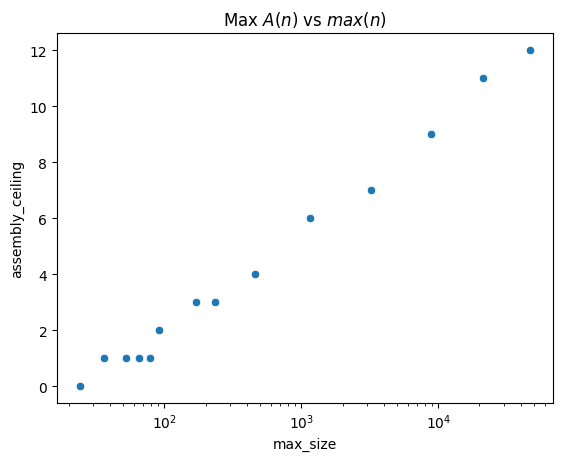

In [70]:

sns.scatterplot(data=evolution,x="max_size",y="assembly_ceiling")
plt.xscale("log")
plt.title(r"Max $A(n)$ vs $max(n)$")
plt.show()

In [10]:
a.pool[a.pool.assembly_efficiency < 1]

,element,copy_number,size,balanced,dyck_word,entropy,assembly,assembly_efficiency,history,steps,lz_comp,has_inversion,ensemble
269,00101100011,1,11,True,False,0.99403,5,0.8,(((((0)(0))((1)(0)))((1)(1)))((((0)(0))(0))((1...,4,4,False,0.000117
604,00011100011,1,11,True,False,0.99403,5,0.8,(((((0)(0))(0))(((1)(1))(1)))((((0)(0))(0))((1...,4,5,False,0.000117


/tmp/ipykernel_243613/2284177951.py:12: RuntimeWarning: invalid value encountered in log
  return a * np.log(b*x) + c


[ 1.39373764  0.14338528 -0.35922477]


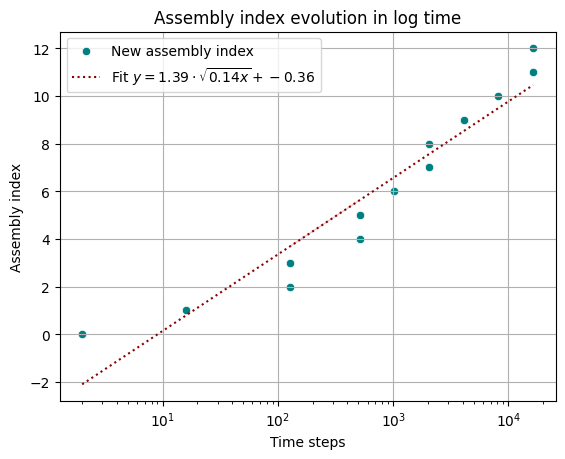

In [58]:
data = np.zeros([np.max(evolution.assembly_ceiling),2])
for i in range(np.max(evolution.assembly_ceiling)):
    tk = np.min(evolution[evolution.assembly_ceiling > i].index)

    data[i,0] = tk
    data[i,1] = i

x = np.power(2,data[:,0])
y = data[:,1]

def func(x,a,b,c):
    return a * np.log(b*x) + c

popt, pcov = curve_fit(func, x, y)
print(popt)
sns.scatterplot(x = x, y = y,color="teal" , label="New assembly index")
sns.lineplot(x=x, y=func(x, *popt),color="darkred",linestyle=":",label=fr"Fit $y ={np.round(popt[0],2)}\cdot\sqrt{{{np.round(popt[1],2)}x}}+{np.round(popt[2],2)}$")
plt.title("Assembly index evolution in log time")
plt.xlabel("Time steps")
plt.ylabel("Assembly index")
plt.xscale("log")
plt.grid(which="major")
plt.legend()
plt.show()


| n0 = n1 = N/2 | Time steps    |exponent               |
|----------     |----------     |---------              |
| 1             | 1000          | 3.46 x log(3.9x)      |
| 5             | 1000          | 3.04 x log(0.7x)      |
| 10            | 1000          | 2.31 x log(0.43x)     |
| 25            | 8000          | 2.14 x log(0.39x)     |
| 50            | 8000          | 2.01 x log(1.19x)     |
| 100           | 8000          | 1.72 x log(1.24x)     |
| 500           | 20000         | 1.35 x log(0.59x)     |
| 1000          | 20000         | 1.27 x log(2.93x)     |


In [6]:
sims = 300
steps = 10000
evol_steps = 16
N =40 
assemblies = np.zeros([sims,evol_steps])
entropies = np.zeros([sims,evol_steps])
steps_array = np.zeros([sims,evol_steps])
for i in range(sims):
   print(f"Iteration {i} of {sims}")
   a = ap.AssemblyPool(int(N/2),int(N/2))
   evolution = a.evolve(steps)
   assemblies[i,:] = evolution.assembly_ceiling
   entropies[i,:] = evolution.ensemble_entropy
   steps_array[i,:] = evolution.max_steps

entropy_df = pd.DataFrame(entropies,columns=range(evol_steps)).melt(var_name = "measurement", value_name="value")
assembly_df= pd.DataFrame(assemblies,columns=range(evol_steps)).melt(var_name = "measurement", value_name="value")
steps_df= pd.DataFrame(steps_array,columns=range(evol_steps)).melt(var_name = "measurement", value_name="value")

entropy_df.to_pickle(f"entropy_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
assembly_df.to_pickle(f"assembly_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
steps_df.to_pickle(f"steps_df_s{sims}_n{N}_t{int(steps/1000)}k.plk")

# entropy_df = pd.read_pickle(f"entropy_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
# steps_df = pd.read_pickle(f"steps_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
# assembly_df = pd.read_pickle(f"assembly_s{sims}_n{N}_t{int(steps/1000)}k.pkl")

Iteration 0 of 300


Calculating iterations: 100%|██████████| 10000/10000 [01:02<00:00, 161.01it/s]


Iteration 1 of 300


Calculating iterations: 100%|██████████| 10000/10000 [01:03<00:00, 158.64it/s]


Iteration 2 of 300


...

Calculating iterations: 100%|██████████| 10000/10000 [00:49<00:00, 203.22it/s]


Iteration 298 of 300


Calculating iterations: 100%|██████████| 10000/10000 [00:49<00:00, 200.07it/s]


Iteration 299 of 300


Calculating iterations: 100%|██████████| 10000/10000 [00:54<00:00, 184.64it/s]


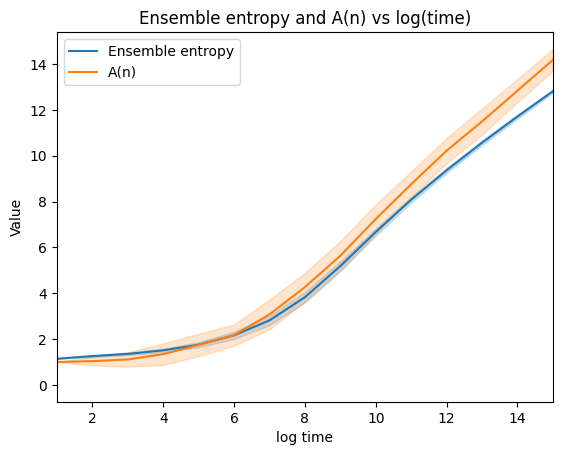

In [7]:
sns.lineplot(data=entropy_df, x="measurement", y="value",errorbar="sd",label="Ensemble entropy" )
sns.lineplot(data=assembly_df, x="measurement", y="value",errorbar="sd", label="A(n)")
plt.xlabel("log time")
plt.title("Ensemble entropy and A(n) vs log(time)")
plt.ylabel("Value")
# plt.yscale("log")
plt.xlim([1,15])
plt.legend()
plt.show()

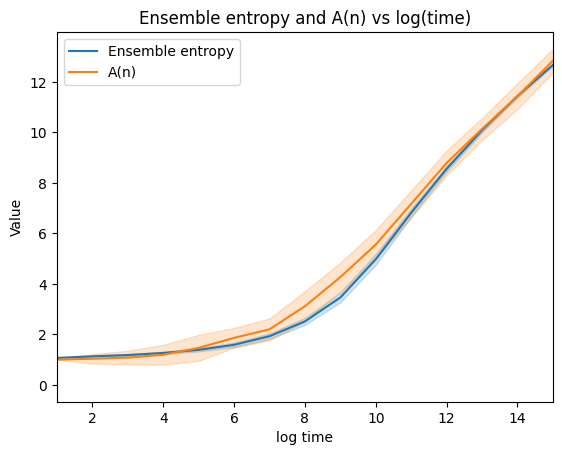

In [17]:
sns.lineplot(data=entropy_df, x="measurement", y="value",errorbar="sd",label="Ensemble entropy" )
sns.lineplot(data=assembly_df, x="measurement", y="value",errorbar="sd", label="A(n)")
plt.xlabel("log time")
plt.title("Ensemble entropy and A(n) vs log(time)")
plt.ylabel("Value")
# plt.yscale("log")
plt.xlim([1,15])
plt.legend()
plt.show()

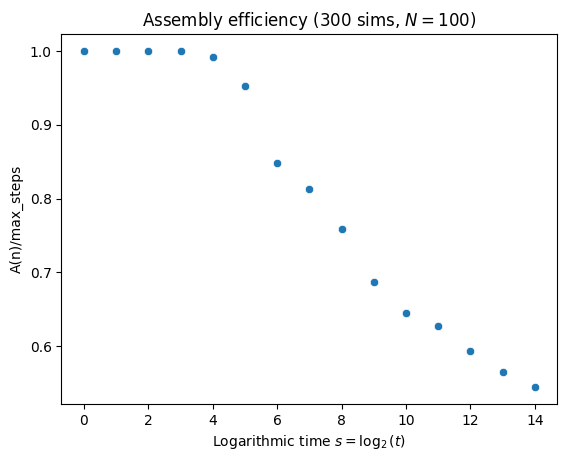

In [35]:
efficiency = assembly_df[steps_df.value > 0].value / steps_df[steps_df.value > 0 ].value 
eff_mean = np.zeros(15)
for i in range(len(eff_mean)):
    eff_mean[i] = np.mean(efficiency[300*i:300*(i+1)]) 

sns.scatterplot(x = np.arange(15), y = eff_mean)
plt.title(r"Assembly efficiency (300 sims, $N = 100$)")
plt.xlabel(r"Logarithmic time $s = \log_2(t)$")
plt.ylabel("A(n)/max_steps")
plt.show()